# Portfolio Visualisations

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

PORTFOLIO_DATA_DIR = Path("portfolio_data")

if not PORTFOLIO_DATA_DIR.exists():
    raise FileNotFoundError(
        "portfolio_data folder not found. "
        "Run this notebook from the project root."
    )

csv_files = sorted(PORTFOLIO_DATA_DIR.glob("*.csv"))

print(f"Portfolio datasets found: {len(csv_files)}")
print("-" * 50)

for file in csv_files:
    print(f"✓ {file.name}")

if len(csv_files) != 16:
    raise RuntimeError(
        f"Expected 16 frozen portfolio datasets, found {len(csv_files)}."
    )

print("-" * 50)
print("✓ All 16 frozen research datasets found.")

Portfolio datasets found: 16
--------------------------------------------------
✓ 01_event_study_events.csv
✓ 01_recovery_by_stock.csv
✓ 02_baseline_summary.csv
✓ 02_control_hit_rate_simulations.csv
✓ 03_excursion_comparison.csv
✓ 03_forward_return_comparison.csv
✓ 03_forward_return_control_simulations.csv
✓ 04_strategy_comparison.csv
✓ 05_baseline_strategy.csv
✓ 05_bootstrap_interval.csv
✓ 05_leave_one_ticker_out.csv
✓ 05_market_regimes.csv
✓ 05_period_robustness.csv
✓ 05_threshold_sensitivity.csv
✓ 05_transaction_cost_sensitivity.csv
✓ 05_year_summary.csv
--------------------------------------------------
✓ All 16 frozen research datasets found.


## 2. Import Analytical Datasets & Validate

Each dataset represents a specific stage of the completed research pipeline:

- **Event study:** observed large-drop events and subsequent recovery
- **Matched baseline:** simulated ordinary trading days used as a statistical comparison
- **Forward returns:** post-event return paths and price excursions
- **Strategy backtest:** comparison of executable exit rules
- **Robustness:** sensitivity to signal thresholds, sample composition, time periods, market regimes, and transaction costs

In [2]:
# 01 — Event study
event_study = pd.read_csv(
    PORTFOLIO_DATA_DIR / "01_event_study_events.csv"
)

recovery_by_stock = pd.read_csv(
    PORTFOLIO_DATA_DIR / "01_recovery_by_stock.csv"
)


# 02 — Matched-control baseline
baseline_summary = pd.read_csv(
    PORTFOLIO_DATA_DIR / "02_baseline_summary.csv"
)

control_hit_rates = pd.read_csv(
    PORTFOLIO_DATA_DIR / "02_control_hit_rate_simulations.csv"
)


# 03 — Forward-return analysis
forward_returns = pd.read_csv(
    PORTFOLIO_DATA_DIR / "03_forward_return_comparison.csv"
)

excursions = pd.read_csv(
    PORTFOLIO_DATA_DIR / "03_excursion_comparison.csv"
)

forward_control_simulations = pd.read_csv(
    PORTFOLIO_DATA_DIR / "03_forward_return_control_simulations.csv"
)


# 04 — Executable strategy comparison
strategy_comparison = pd.read_csv(
    PORTFOLIO_DATA_DIR / "04_strategy_comparison.csv"
)


# 05 — Robustness analysis
robustness_baseline = pd.read_csv(
    PORTFOLIO_DATA_DIR / "05_baseline_strategy.csv"
)

bootstrap_interval = pd.read_csv(
    PORTFOLIO_DATA_DIR / "05_bootstrap_interval.csv"
)

leave_one_out = pd.read_csv(
    PORTFOLIO_DATA_DIR / "05_leave_one_ticker_out.csv"
)

market_regimes = pd.read_csv(
    PORTFOLIO_DATA_DIR / "05_market_regimes.csv"
)

period_robustness = pd.read_csv(
    PORTFOLIO_DATA_DIR / "05_period_robustness.csv"
)

threshold_sensitivity = pd.read_csv(
    PORTFOLIO_DATA_DIR / "05_threshold_sensitivity.csv"
)

transaction_costs = pd.read_csv(
    PORTFOLIO_DATA_DIR / "05_transaction_cost_sensitivity.csv"
)

year_summary = pd.read_csv(
    PORTFOLIO_DATA_DIR / "05_year_summary.csv"
)

print("✓ All frozen analytical datasets loaded.")

✓ All frozen analytical datasets loaded.


In [3]:
datasets = {
    "Event study": event_study,
    "Recovery by stock": recovery_by_stock,
    "Baseline summary": baseline_summary,
    "Control hit-rate simulations": control_hit_rates,
    "Forward returns": forward_returns,
    "Excursions": excursions,
    "Forward control simulations": forward_control_simulations,
    "Strategy comparison": strategy_comparison,
    "Robustness baseline": robustness_baseline,
    "Bootstrap interval": bootstrap_interval,
    "Leave-one-out": leave_one_out,
    "Market regimes": market_regimes,
    "Period robustness": period_robustness,
    "Threshold sensitivity": threshold_sensitivity,
    "Transaction costs": transaction_costs,
    "Year summary": year_summary
}

for name, df in datasets.items():
    print("=" * 70)
    print(name.upper())
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print()
    print(df.head().to_string(index=False))
    print()

EVENT STUDY
Shape: (60, 6)
Columns: ['Date', 'Ticker', 'Daily_Return', 'Event_Price', 'Max_Recovery_10D', 'Recovered_5pct_10D']

      Date Ticker  Daily_Return  Event_Price  Max_Recovery_10D  Recovered_5pct_10D
2017-02-23   NVDA     -0.092723     2.472113          0.039009               False
2018-02-05   NVDA     -0.084875     5.270975          0.165559                True
2018-02-20    WMT     -0.101832    27.425879         -0.010520               False
2018-07-26   META     -0.189609   174.725647          0.053500                True
2018-10-24   NVDA     -0.097937     4.927301          0.093777                True

RECOVERY BY STOCK
Shape: (10, 4)
Columns: ['Ticker', 'Events', 'Successful_Recoveries', 'Hit_Rate']

Ticker  Events  Successful_Recoveries  Hit_Rate
  MSFT       2                      2       1.0
   JPM       5                      4       0.8
  META      10                      7       0.7
  AAPL       5                      3       0.6
  AMZN       5                 

In [4]:
print("DATA QUALITY CHECK")
print("=" * 70)

for name, df in datasets.items():
    duplicate_rows = df.duplicated().sum()
    missing_values = df.isna().sum().sum()

    print(
        f"{name:<30} "
        f"rows={len(df):>5} | "
        f"duplicates={duplicate_rows:>3} | "
        f"missing={missing_values:>3}"
    )

DATA QUALITY CHECK
Event study                    rows=   60 | duplicates=  0 | missing=  0
Recovery by stock              rows=   10 | duplicates=  0 | missing=  0
Baseline summary               rows=    6 | duplicates=  0 | missing=  0
Control hit-rate simulations   rows= 1000 | duplicates=978 | missing=  0
Forward returns                rows=    4 | duplicates=  0 | missing=  0
Excursions                     rows=    2 | duplicates=  0 | missing=  0
Forward control simulations    rows= 4000 | duplicates=  0 | missing=  0
Strategy comparison            rows=    5 | duplicates=  0 | missing=  0
Robustness baseline            rows=    1 | duplicates=  0 | missing=  0
Bootstrap interval             rows=    2 | duplicates=  0 | missing=  0
Leave-one-out                  rows=   10 | duplicates=  0 | missing=  0
Market regimes                 rows=    2 | duplicates=  0 | missing=  0
Period robustness              rows=    3 | duplicates=  0 | missing=  0
Threshold sensitivity          r

## 3. Visual Design System

### Design principles

- **Editorial hierarchy:** Titles communicate the finding.
- **Narrative context:** A short subtitle explains what is being measured and why it matters.
- **Restrained colour:** The Chromis Vanderbilti palette provides the visual identity, with only the colours necessary for each figure used.
- **Direct labelling:** Data is labelled within the graphic wherever possible, reducing reliance on legends.
- **Minimal chart furniture:** Axes, gridlines, and reference lines remain visible only where they aid interpretation.
- **Consistent analytical roles:** Extreme-drop observations, matched controls, selected strategies, and alternative specifications retain consistent visual treatment across figures.
- **White canvas:** Figures are designed to sit naturally within the white background of the portfolio website.

### Fonts

In [15]:
from pathlib import Path
from matplotlib import font_manager

# Find the static font files installed on Windows.
font_dirs = [
    Path.home() / "AppData/Local/Microsoft/Windows/Fonts",
    Path("C:/Windows/Fonts")
]

wanted_fonts = [
    "PlayfairDisplay-Regular.ttf",
    "PlayfairDisplay-Bold.ttf",
    "RobotoCondensed-Regular.ttf",
    "RobotoCondensed-Medium.ttf",
    "RobotoCondensed-Bold.ttf",
]

font_paths = {}

for folder in font_dirs:
    if not folder.exists():
        continue

    for path in folder.iterdir():
        if path.name in wanted_fonts:
            font_paths[path.name] = path

print("STATIC FONT FILES")
print("=" * 60)

for name in wanted_fonts:
    if name in font_paths:
        print(f"✓ {name}")
    else:
        print(f"✗ {name}")

STATIC FONT FILES
✓ PlayfairDisplay-Regular.ttf
✓ PlayfairDisplay-Bold.ttf
✓ RobotoCondensed-Regular.ttf
✓ RobotoCondensed-Medium.ttf
✓ RobotoCondensed-Bold.ttf


In [16]:
PLAYFAIR_REGULAR = font_manager.FontProperties(
    fname=str(font_paths["PlayfairDisplay-Regular.ttf"])
)

PLAYFAIR_BOLD = font_manager.FontProperties(
    fname=str(font_paths["PlayfairDisplay-Bold.ttf"])
)

ROBOTO_REGULAR = font_manager.FontProperties(
    fname=str(font_paths["RobotoCondensed-Regular.ttf"])
)

ROBOTO_MEDIUM = font_manager.FontProperties(
    fname=str(font_paths["RobotoCondensed-Medium.ttf"])
)

ROBOTO_BOLD = font_manager.FontProperties(
    fname=str(font_paths["RobotoCondensed-Bold.ttf"])
)

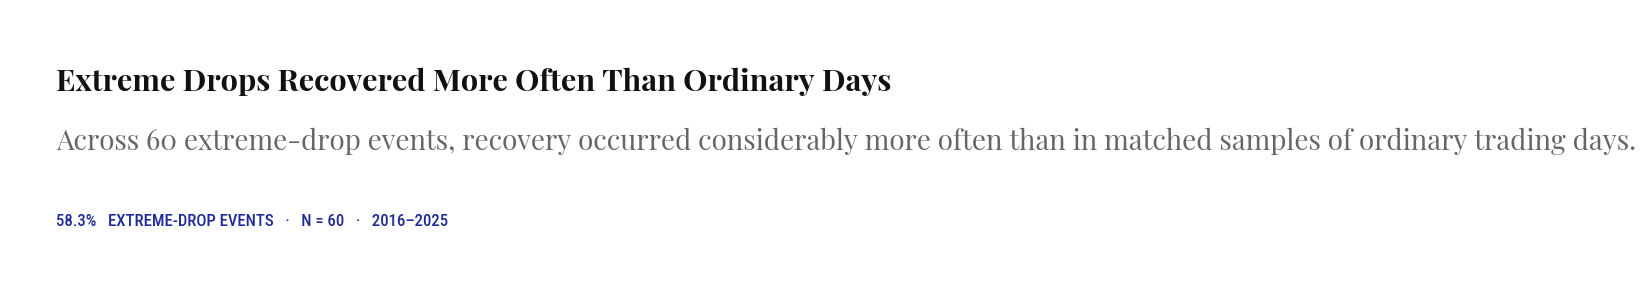

In [19]:
fig, ax = plt.subplots(figsize=(12, 3.5))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

ax.text(
    0.05,
    0.70,
    "Extreme Drops Recovered More Often Than Ordinary Days",
    transform=ax.transAxes,
    fontproperties=PLAYFAIR_BOLD,
    fontsize=22,
    color="#111111"
)

ax.text(
    0.05,
    0.48,
    "Across 60 extreme-drop events, recovery occurred considerably more often "
    "than in matched samples of ordinary trading days.",
    transform=ax.transAxes,
    fontproperties=PLAYFAIR_REGULAR,
    fontsize=20,
    color="#666666"
)

ax.text(
    0.05,
    0.20,
    "58.3%   EXTREME-DROP EVENTS   ·   N = 60   ·   2016–2025",
    transform=ax.transAxes,
    fontproperties=ROBOTO_MEDIUM,
    fontsize=12,
    color=chromis_colors[1]
)

plt.show()

### Color Palette

In [21]:
#%pip install pypalettes -q
from pypalettes import load_cmap

chromis = load_cmap("Chromis_vanderbilti")

# Sample the complete palette so we can inspect its available colours.
chromis_colors = chromis.colors

print(f"Chromis Vanderbilti colours: {len(chromis_colors)}")
print()

for i, color in enumerate(chromis_colors):
    print(f"{i:>2}  {color}")

Chromis Vanderbilti colours: 5

 0  #0D132AFF
 1  #1F2B98FF
 2  #808FFCFF
 3  #EEE115FF
 4  #D69209FF


### Make a swatch

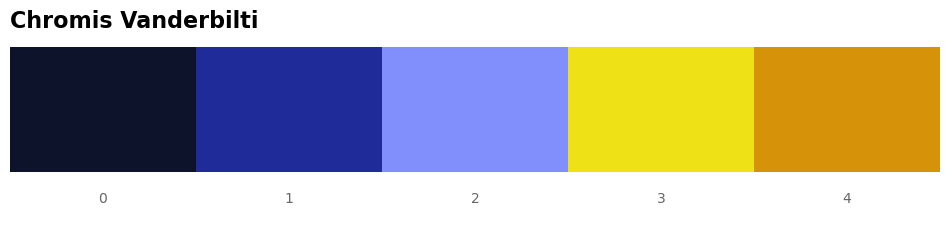

In [22]:
fig, ax = plt.subplots(figsize=(12, 2.2))

for i, color in enumerate(chromis_colors):
    ax.add_patch(
        plt.Rectangle(
            (i, 0),
            1,
            1,
            facecolor=color,
            edgecolor="none"
        )
    )

    ax.text(
        i + 0.5,
        -0.15,
        str(i),
        ha="center",
        va="top",
        fontsize=10,
        color="#666666"
    )

ax.set_xlim(0, len(chromis_colors))
ax.set_ylim(-0.35, 1)
ax.axis("off")

ax.set_title(
    "Chromis Vanderbilti",
    loc="left",
    fontsize=16,
    fontweight="bold",
    pad=14
)

plt.show()

In [25]:
# Base colours
WHITE = "#FFFFFF"
BLACK = "#111111"
GREY = "#6B6B6B"
LIGHT_GREY = "#D9D9D9"
VERY_LIGHT_GREY = "#EEEEEE"

# Chromis Vanderbilti palette
CHROMIS_0 = chromis_colors[0]  # deep navy
CHROMIS_1 = chromis_colors[1]  # cobalt
CHROMIS_2 = chromis_colors[2]  # periwinkle
CHROMIS_3 = chromis_colors[3]  # yellow
CHROMIS_4 = chromis_colors[4]  # ochre

# Standard portfolio figure settings
FIGURE_SIZE = (11, 6.8)
EXPORT_DPI = 300

## 4. Visual 1: Extreme Drops vs. Ordinary Days

### Recovery After an Extreme Drop

The first stage of the analysis asks whether the apparent recovery following an extreme single-day decline is unusual.

The observed recovery rate across 60 extreme-drop events is compared with the distribution produced by 1,000 matched samples of ordinary trading days.

In [23]:
# Pull the frozen results used in the first portfolio graphic.

event_rate = baseline_summary.loc[
    baseline_summary["Metric"] == "Event_Hit_Rate",
    "Value"
].iloc[0]

control_mean = baseline_summary.loc[
    baseline_summary["Metric"] == "Mean_Control_Hit_Rate",
    "Value"
].iloc[0]

control_lower = baseline_summary.loc[
    baseline_summary["Metric"] == "Control_2.5pct",
    "Value"
].iloc[0]

control_upper = baseline_summary.loc[
    baseline_summary["Metric"] == "Control_97.5pct",
    "Value"
].iloc[0]

control_distribution = (
    control_hit_rates["Control_Hit_Rate"].to_numpy() * 100
)

print(f"Extreme-drop recovery rate: {event_rate:.1%}")
print(f"Matched-control mean:       {control_mean:.1%}")
print(f"95% control range:          {control_lower:.1%} – {control_upper:.1%}")
print(f"Control simulations:        {len(control_distribution):,}")

Extreme-drop recovery rate: 58.3%
Matched-control mean:       35.8%
95% control range:          25.0% – 48.3%
Control simulations:        1,000


✓ Saved to: graphic_01_extreme_drops_vs_ordinary_days.jpg


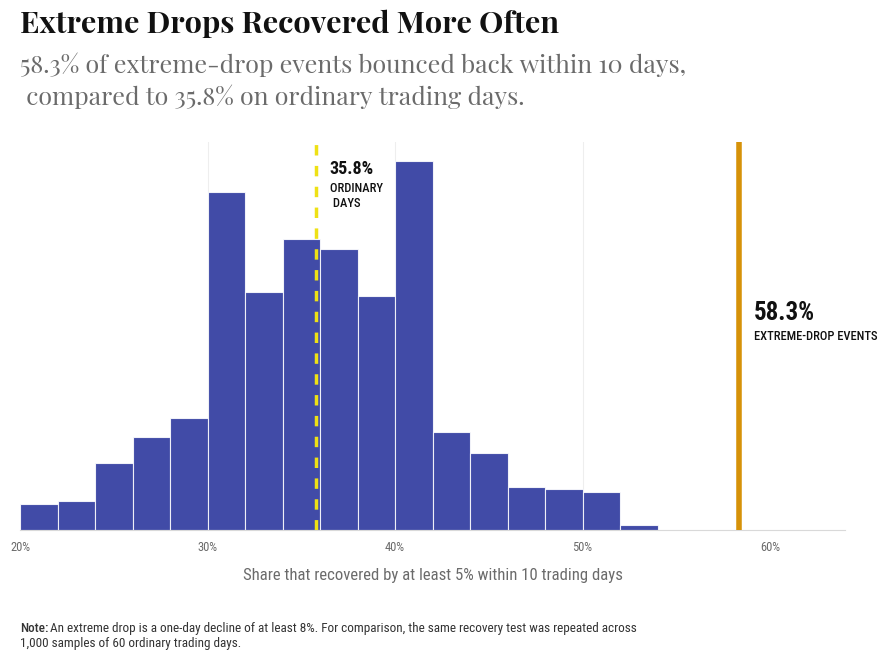

In [113]:
# ---------------------------------------------------------
# GRAPHIC 01
# Extreme drops vs. matched ordinary days
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6.8))

fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

# Leave generous editorial space above the plotting area.
#the subplot is the data visualisation size, not the title and subtitle. 
fig.subplots_adjust(left=0.10, right=0.85, bottom=0.18, top=0.75)

# ---------------------------------------------------------
# CONTROL DATA DISTRIBUTION
# ---------------------------------------------------------
bins = np.arange(20, 56, 2)
ax.hist(control_distribution, bins=bins,
    color=CHROMIS_1, #color of the histogram
    alpha=0.85, #transparency
    edgecolor=WHITE, linewidth=0.8)

# ---------------------------------------------------------
# REFERENCE LINES
# ---------------------------------------------------------

# Mean recovery rate among matched ordinary-day samples.
ax.axvline(control_mean * 100,
    color=CHROMIS_3, #yellow
    linewidth=2.5, linestyle=(0, (3, 3)),
    zorder=4 #order in which elements are layered
)

# Observed recovery rate after extreme drops.
ax.axvline(event_rate * 100,
    color=CHROMIS_4, #orange
    linewidth=4, #thick line
    zorder=5 #order in which elements are layered
)

# ---------------------------------------------------------
# EDITORIAL TITLE + DECK
# ---------------------------------------------------------

fig.text(0.10,0.91,"Extreme Drops Recovered More Often",
    fontproperties=PLAYFAIR_BOLD, #title font 
    fontsize=22, #title font size 
    color=BLACK, #title color
    ha="left"
)

fig.text(0.10,0.805, "58.3% of extreme-drop events bounced back within 10 days, \n " "compared to 35.8% on ordinary trading days. ",
    fontproperties=PLAYFAIR_REGULAR, #subtitle font 
    fontsize=18, #subtitle font size 
    color=GREY, #subtitle color 
    ha="left",
    linespacing=1.35
)

# ---------------------------------------------------------
# DIRECT ANNOTATIONS
# ---------------------------------------------------------

ymax = ax.get_ylim()[1]

# Event result
ax.text(
    event_rate * 100 + 0.8,
    ymax * 0.56, f"{event_rate:.1%}",
    fontproperties=ROBOTO_BOLD,
fontsize=18,color=BLACK,
va="center"
)

ax.text(
    event_rate * 100 + 0.8,
    ymax * 0.50, "EXTREME-DROP EVENTS",
    fontproperties=ROBOTO_MEDIUM,
    fontsize=9,
    color=BLACK,
    va="center"
)

# Matched-control mean
ax.text(
    control_mean * 100 + 0.7,
    ymax * 0.93,
    "35.8%",
    fontproperties=ROBOTO_BOLD,
    fontsize=13,
    color=BLACK,
    ha="left",
    va="center"
)

ax.text(
    control_mean * 100 + 0.7,
    ymax * 0.86,
    "ORDINARY \n DAYS",
    fontproperties=ROBOTO_MEDIUM,
    fontsize=9,
    color=BLACK,
    ha="left",
    va="center"
)
# ax.text(control_mean * 100 - 0.8, ymax * 0.90, f"CONTROL MEAN  {control_mean:.1%}", fontproperties=ROBOTO_MEDIUM, fontsize=9, color=BLACK,
#     ha="right",
#     va="center"
# )

# ---------------------------------------------------------
# AXES
# ---------------------------------------------------------

ax.set_xlim(20, 64)

ax.set_xticks([20, 30, 40, 50, 60])
ax.set_xticklabels(
    ["20%", "30%", "40%", "50%", "60%"],
    fontproperties=ROBOTO_REGULAR,
    fontsize=9,
    color=GREY
)

ax.set_yticks([])

ax.set_xlabel(
    "Share that recovered by at least 5% within 10 trading days",
    fontproperties=ROBOTO_REGULAR,
    fontsize=12,
    color=GREY,
    labelpad=10
)

# Minimal NYT-style chart furniture.
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color(LIGHT_GREY)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(
    axis="x",
    length=0,
    pad=8
)

# Very light vertical reference guides.
for x in [30, 40, 50]:
    ax.axvline(
        x,
        color=VERY_LIGHT_GREY,
        linewidth=0.8,
        zorder=0
    )

# ---------------------------------------------------------
# METHODOLOGY NOTE
# ---------------------------------------------------------

fig.text(
    0.10,
    0.045,
    "Note:",
    fontproperties=ROBOTO_MEDIUM,
    fontsize=9.5,
    color=BLACK,
    alpha=0.85,
    ha="left",
    va="top"
)
fig.text(
    0.10,
    0.045,
    "          An extreme drop is a one-day decline of at least 8%. For comparison, the same recovery test was repeated across \n"
    "1,000 samples of 60 ordinary trading days.", 
    fontproperties=ROBOTO_REGULAR,
    fontsize=9.5,
    color=BLACK,
    alpha=0.85,
    ha="left",
    va="top",
    linespacing=1.25
)

# ---------------------------------------------------------
# EXPORT
# ---------------------------------------------------------

output_path = "graphic_01_extreme_drops_vs_ordinary_days.jpg"

fig.savefig(
    output_path,
    format="jpg",
    dpi=300,
    bbox_inches="tight",
    facecolor=WHITE,
    pil_kwargs={"quality": 95}
)

print(f"✓ Saved to: {output_path}")

plt.show()

## 5. Visual 2: Forward Returns after an Extreme Market Drop

### How Did Returns Evolve After the Initial Fall?

The recovery-rate analysis shows that extreme-drop events were more likely to rebound. 

Next, we look at how the returns evolved over the following trading days after an extreme-drop event and whether this difference persisted beyond a single recovery threshold. 

In [114]:
print("FORWARD RETURN COMPARISON")
print("=" * 70)
print(forward_returns.to_string(index=False))

print("\nCOLUMNS")
print("=" * 70)
print(forward_returns.columns.tolist())

FORWARD RETURN COMPARISON
 Horizon_Days  Event_Mean_Return  Control_Mean_Return  Mean_Return_Difference  Event_Median_Return  Control_Median_Return  Event_Positive_Rate  Control_Positive_Rate  Control_Mean_2.5pct  Control_Mean_97.5pct  Control_Sims_At_Or_Above_Event_Mean
            1           0.020960             0.001396                0.019565             0.019012               0.001319             0.616667               0.536200            -0.004761              0.007105                                0.000
            3          -0.009586             0.004545               -0.014131            -0.011457               0.004409             0.416667               0.565417            -0.005739              0.014276                                0.995
            5          -0.012268             0.007656               -0.019924            -0.014363               0.007241             0.450000               0.582867            -0.005227              0.019311                            

In [115]:
print("FORWARD CONTROL SIMULATIONS")
print("=" * 70)
print(forward_control_simulations.head(10).to_string(index=False))

print("\nCOLUMNS")
print("=" * 70)
print(forward_control_simulations.columns.tolist())

print(f"\nRows: {len(forward_control_simulations):,}")

FORWARD CONTROL SIMULATIONS
 Simulation  Horizon_Days  Mean_Return  Median_Return  Positive_Rate
          0             1     0.002982       0.005728       0.566667
          0             3     0.013574       0.012053       0.616667
          0             5     0.007261       0.006558       0.600000
          0            10    -0.002396      -0.001992       0.483333
          1             1    -0.000768       0.000523       0.500000
          1             3     0.002026       0.003497       0.550000
          1             5     0.010507       0.000573       0.533333
          1            10     0.026854       0.025763       0.650000
          2             1     0.004386       0.000627       0.533333
          2             3     0.006625       0.003099       0.516667

COLUMNS
['Simulation', 'Horizon_Days', 'Mean_Return', 'Median_Return', 'Positive_Rate']

Rows: 4,000


In [116]:
# ---------------------------------------------------------
# GRAPHIC 02 — DATA PREPARATION
# Forward returns after extreme drops
# ---------------------------------------------------------

forward_plot = forward_returns.copy()

# Convert decimal returns into percentages so that:
# 0.02096 becomes 2.096 rather than 0.02096.
percentage_columns = [
    "Event_Mean_Return",
    "Control_Mean_Return",
    "Control_Mean_2.5pct",
    "Control_Mean_97.5pct"
]

for column in percentage_columns:
    forward_plot[column] = forward_plot[column] * 100

# Give each horizon a reader-friendly label.
forward_plot["Horizon_Label"] = (
    forward_plot["Horizon_Days"]
    .astype(int)
    .astype(str)
    + " day"
)

# Make the plural labels grammatically correct.
forward_plot.loc[
    forward_plot["Horizon_Days"] > 1,
    "Horizon_Label"
] += "s"

forward_plot[
    [
        "Horizon_Label",
        "Event_Mean_Return",
        "Control_Mean_Return",
        "Control_Mean_2.5pct",
        "Control_Mean_97.5pct"
    ]
]

,Horizon_Label,Event_Mean_Return,Control_Mean_Return,Control_Mean_2.5pct,Control_Mean_97.5pct
0,1 day,2.096039,0.139564,-0.476140,0.710481
1,3 days,-0.958629,0.454502,-0.573931,1.427559
2,5 days,-1.226765,0.765644,-0.522709,1.931095
3,10 days,2.651923,1.511234,-0.284195,3.220730


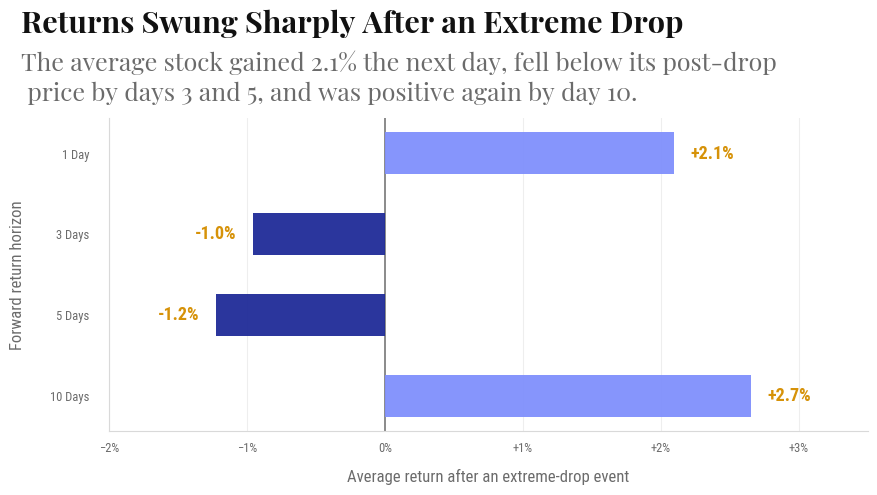

In [127]:
# ---------------------------------------------------------
# GRAPHIC 02
# Forward returns after extreme drops
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6.8))

fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

# Match the editorial composition established in Graphic 01.
#to move the bars closer or further away from one another, use the subplot adjust option
fig.subplots_adjust(
    left=0.16,
    right=0.85,
    bottom=0.22, #bottom of the plotting area
    top=0.68 #top of the plotting area
)

# ---------------------------------------------------------
# DATA
# ---------------------------------------------------------

# Put the shortest horizon at the top.
y_positions = np.arange(len(forward_plot))[::-1]

event_returns = forward_plot["Event_Mean_Return"].to_numpy()

# ---------------------------------------------------------
# BARS
# ---------------------------------------------------------

#construct a color list based on whether the value is positive or negative 
bar_colors = [
    CHROMIS_2 if value >= 0 else CHROMIS_1
    for value in event_returns
]

ax.barh(
    y_positions,
    event_returns,
    height=0.52,
    color=bar_colors,
    alpha=0.95,
    zorder=2
)

# ---------------------------------------------------------
# ZERO LINE
# ---------------------------------------------------------

# Everything to the right is a gain;
# everything to the left is a loss.
ax.axvline(
    0,
    color=GREY,
    linewidth=1.1,
    zorder=1
)

# ---------------------------------------------------------
# DIRECT VALUE LABELS
# ---------------------------------------------------------

for y, value in zip(y_positions, event_returns):

    if value >= 0:
        label_x = value + 0.12
        alignment = "left"
    else:
        label_x = value - 0.12
        alignment = "right"

    ax.text(
        label_x,
        y,
        f"{value:+.1f}%",
        fontproperties=ROBOTO_BOLD,
        fontsize=13,
        color=CHROMIS_4,
        ha=alignment,
        va="center"
    )

# ---------------------------------------------------------
# EDITORIAL TITLE + SUBTITLE
# ---------------------------------------------------------

fig.text(
    0.08,
    0.805,
    "Returns Swung Sharply After an Extreme Drop",
    fontproperties=PLAYFAIR_BOLD,
    fontsize=22,
    color=BLACK,
    ha="left"
)

fig.text(
    0.08,
    0.705,
    "The average stock gained 2.1% the next day, fell below its post-drop \n price by days 3 and 5, and was positive again by day 10.",
    fontproperties=PLAYFAIR_REGULAR,
    fontsize=18,
    color=GREY,
    ha="left",
    linespacing=1.35
)

# ---------------------------------------------------------
# Y AXIS
# ---------------------------------------------------------

ax.set_yticks(y_positions)

ax.set_yticklabels(
    ["1 Day", "3 Days", "5 Days", "10 Days"],
    fontproperties=ROBOTO_REGULAR,
    fontsize=9,
    color=GREY
)

ax.set_ylabel(
    "Forward return horizon",
    fontproperties=ROBOTO_REGULAR,
    fontsize=12,
    color=GREY,
    labelpad=18
)

# ---------------------------------------------------------
# X AXIS
# ---------------------------------------------------------

ax.set_xlim(-2.0, 3.5)

ax.set_xticks([-2, -1, 0, 1, 2, 3])

ax.set_xticklabels(
    ["−2%", "−1%", "0%", "+1%", "+2%", "+3%"],
    fontproperties=ROBOTO_REGULAR,
    fontsize=9,
    color=GREY
)

ax.set_xlabel(
    "Average return after an extreme-drop event",
    fontproperties=ROBOTO_REGULAR,
    fontsize=12,
    color=GREY,
    labelpad=10
)

# ---------------------------------------------------------
# CHART FURNITURE
# ---------------------------------------------------------

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_visible(True)
ax.spines["left"].set_color(LIGHT_GREY)
ax.spines["left"].set_linewidth(0.8)

ax.spines["bottom"].set_color(LIGHT_GREY)
ax.spines["bottom"].set_linewidth(0.8)

ax.spines["bottom"].set_color(LIGHT_GREY)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(
    axis="x",
    length=0,
    pad=8
)

ax.tick_params(
    axis="y",
    length=0,
    pad=14
)

# Very light vertical guides.
for x in [-2, -1, 1, 2, 3]:
    ax.axvline(
        x,
        color=VERY_LIGHT_GREY,
        linewidth=0.8,
        zorder=0
    )

plt.show()

In [128]:
# ---------------------------------------------------------
# SAVE PORTFOLIO IMAGE
# ---------------------------------------------------------

output_path = "02_forward_return_horizons.jpg"

fig.savefig(
    output_path,
    format="jpg",
    dpi=300,
    bbox_inches="tight",
    facecolor=WHITE
)

print(f"Saved: {output_path}")

plt.show()

Saved: 02_forward_return_horizons.jpg


## 6. Visual 3: Trading Strategies

Looking at different trading strategies. What happens if you hold for 1 day, if you hold for 3 days, if you hold for 5 days, if you hold for 10 days while analysing historic data over the past 10 years - the 60 extreme-drop events identified in the 10 stock universe. 

In [130]:
# ---------------------------------------------------------
# GRAPHIC 03 — INSPECT STRATEGY COMPARISON DATA
# ---------------------------------------------------------

print("STRATEGY COMPARISON")
print("=" * 70)

display(strategy_comparison)

print("\nCOLUMNS")
print("=" * 70)
print(strategy_comparison.columns.tolist())

STRATEGY COMPARISON


,Strategy,Trades,Skipped_Overlap_Signals,Win_Rate,Mean_Net_Return,Median_Net_Return,Profit_Factor,Best_Trade,Worst_Trade,Average_Holding_Sessions,Average_MFE,Average_MAE
0,Hold 1 session,60,0,0.566667,0.012354,0.007306,2.144572,0.111039,-0.106631,1.000000,0.036329,-0.035945
1,Hold 3 sessions,51,9,0.313725,-0.022026,-0.024341,0.360098,0.131539,-0.195715,3.000000,0.043318,-0.068460
2,Hold 5 sessions,49,11,0.285714,-0.022545,-0.031461,0.489176,0.144554,-0.253978,5.000000,0.052162,-0.080751
3,Hold 10 sessions,47,13,0.489362,0.000263,-0.002162,1.007068,0.217591,-0.319822,10.000000,0.074801,-0.095437
4,5% TP / 10-session max,52,8,0.634615,0.001839,0.049000,1.067148,0.049000,-0.319822,6.192308,0.049698,-0.079461



COLUMNS
['Strategy', 'Trades', 'Skipped_Overlap_Signals', 'Win_Rate', 'Mean_Net_Return', 'Median_Net_Return', 'Profit_Factor', 'Best_Trade', 'Worst_Trade', 'Average_Holding_Sessions', 'Average_MFE', 'Average_MAE']


In [138]:
# ---------------------------------------------------------
# GRAPHIC 03 — PROTOTYPE SETUP
# ---------------------------------------------------------

strategy_plot = strategy_comparison.copy()

strategy_plot["Mean_Return_Pct"] = strategy_plot["Mean_Net_Return"] * 100
strategy_plot["Win_Rate_Pct"] = strategy_plot["Win_Rate"] * 100

strategy_plot["Strategy_Label"] = [
    "1 session",
    "3 sessions",
    "5 sessions",
    "10 sessions",
    "5% target"
]

strategy_plot[
    [
        "Strategy_Label",
        "Mean_Return_Pct",
        "Win_Rate_Pct",
        "Profit_Factor"
    ]
]

,Strategy_Label,Mean_Return_Pct,Win_Rate_Pct,Profit_Factor
0,1 session,1.235432,56.666667,2.144572
1,3 sessions,-2.202610,31.372549,0.360098
2,5 sessions,-2.254528,28.571429,0.489176
3,10 sessions,0.026314,48.936170,1.007068
4,5% target,0.183938,63.461538,1.067148


$$ \text{Profit Factor (PF)} = \frac{\text{Gross Profits from Winning Trades}}{\text{Gross Losses from Losing Trades}}$$


Saved: 03_strategy_comparison.jpg


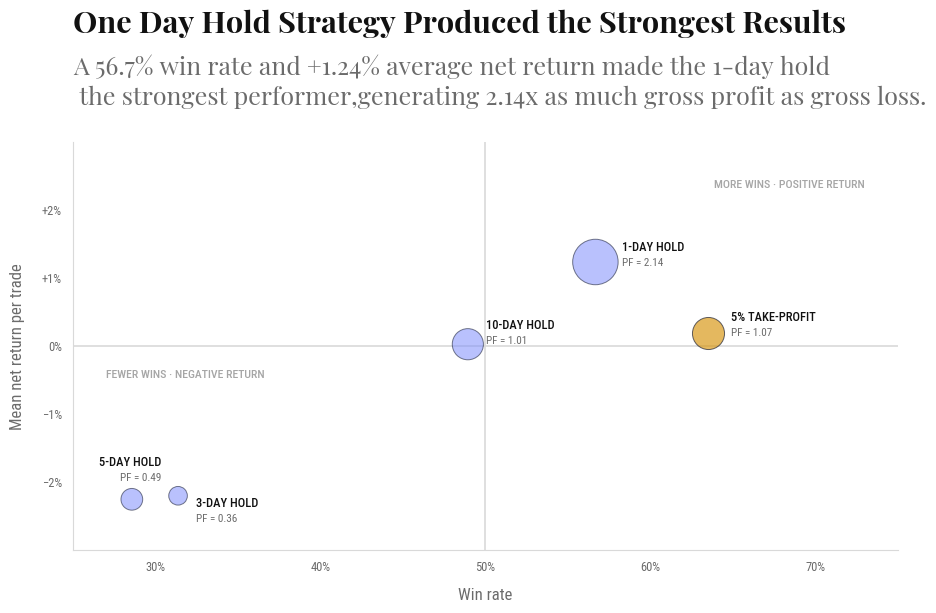

In [166]:
# ---------------------------------------------------------
# GRAPHIC 03
# Strategy comparison:
# Win rate × mean net return × profit factor
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6.8))

fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

# Match the composition used in Graphics 01 and 02.
fig.subplots_adjust(
    left=0.10,
    right=0.85,
    bottom=0.15,
    top=0.75
)


# ---------------------------------------------------------
# DATA
# ---------------------------------------------------------

x = strategy_plot["Win_Rate_Pct"]
y = strategy_plot["Mean_Return_Pct"]

# Bubble AREA represents profit factor.
# The multiplier only controls how large the circles appear.
bubble_sizes = strategy_plot["Profit_Factor"] * 500

# Separate the take-profit strategy from the fixed-hold strategies
# so that it can be styled differently.
take_profit_mask = (
    strategy_plot["Strategy_Label"] == "5% target"
)

fixed_hold_mask = ~take_profit_mask


# ---------------------------------------------------------
# QUADRANT STRUCTURE
# ---------------------------------------------------------

# 50% win rate is the vertical midpoint:
# left = fewer than half of trades won
# right = more than half of trades won
ax.axvline(
    50,
    color=LIGHT_GREY,
    linewidth=1.2,
    zorder=1
)

# 0% mean return is the horizontal midpoint:
# above = positive average return
# below = negative average return
ax.axhline(
    0,
    color=LIGHT_GREY,
    linewidth=1.2,
    zorder=1
)


# ---------------------------------------------------------
# FIXED-HOLD STRATEGIES
# ---------------------------------------------------------

ax.scatter(
    x[fixed_hold_mask],
    y[fixed_hold_mask],
    s=bubble_sizes[fixed_hold_mask],

    # Lighter periwinkle fill
    color=CHROMIS_2,
    alpha=0.55,

    # Thin dark outline
    edgecolor=CHROMIS_0,
    linewidth=0.7,

    zorder=3
)


# ---------------------------------------------------------
# 5% TAKE-PROFIT STRATEGY
# ---------------------------------------------------------

ax.scatter(
    x[take_profit_mask],
    y[take_profit_mask],
    s=bubble_sizes[take_profit_mask],

    # Ochre distinguishes the take-profit rule
    color=CHROMIS_4,
    alpha=0.65,

    edgecolor=CHROMIS_0,
    linewidth=0.7,

    zorder=4
)


# ---------------------------------------------------------
# DIRECT LABELS
# ---------------------------------------------------------

# Each strategy is positioned manually.
# This avoids collisions and gives us editorial control
# over the composition.

label_settings = {

    "1 session": {
        "text": "1-DAY HOLD",
        "dx": 1.6,
        "dy": 0.12,
        "ha": "left"
    },

    "3 sessions": {
        "text": "3-DAY HOLD",
        "dx": 1.1,
        "dy": -0.2,
        "ha": "left"
    },

    "5 sessions": {
        "text": "5-DAY HOLD",
        "dx": 1.80,
        "dy": 0.45,
        "ha": "right"
    },

    "10 sessions": {
        "text": "10-DAY HOLD",
        "dx": 1.1,
        "dy": 0.18,
        "ha": "left"
    },

    "5% target": {
        "text": "5% TAKE-PROFIT",
        "dx": 1.4,
        "dy": 0.15,
        "ha": "left"
    }
}


for _, row in strategy_plot.iterrows():

    settings = label_settings[row["Strategy_Label"]]

    label_x = row["Win_Rate_Pct"] + settings["dx"]
    label_y = row["Mean_Return_Pct"] + settings["dy"]

    # Strategy name
    ax.text(
        label_x,
        label_y,
        settings["text"],
        fontproperties=ROBOTO_MEDIUM,
        fontsize=9,
        color=BLACK,
        ha=settings["ha"],
        va="bottom",
        zorder=5
    )

    # Profit factor
    ax.text(
        label_x,
        label_y - 0.06,
        f"PF = {row['Profit_Factor']:.2f}",
        fontproperties=ROBOTO_REGULAR,
        fontsize=8,
        color=GREY,
        ha=settings["ha"],
        va="top",
        zorder=5
    )


# ---------------------------------------------------------
# QUADRANT CUES
# ---------------------------------------------------------

# Upper-right quadrant.
# Positioned high and right so it does not compete with
# the 1-session strategy.
ax.text(
    73,
    2.45,
    "MORE WINS · POSITIVE RETURN",
    fontproperties=ROBOTO_MEDIUM,
    fontsize=8.5,
    color=GREY,
    alpha=0.60,
    ha="right",
    va="top"
)

# Lower-left quadrant.
# Positioned in the empty interior rather than beside
# the 3- and 5-session bubbles.
ax.text(
    27,
    -0.35,
    "FEWER WINS · NEGATIVE RETURN",
    fontproperties=ROBOTO_MEDIUM,
    fontsize=8.5,
    color=GREY,
    alpha=0.60,
    ha="left",
    va="top"
)


# ---------------------------------------------------------
# EDITORIAL TITLE + SUBTITLE
# ---------------------------------------------------------

fig.text(
    0.10,
    0.91,
    "One Day Hold Strategy Produced the Strongest Results",
    fontproperties=PLAYFAIR_BOLD,
    fontsize=22,
    color=BLACK,
    ha="left"
)

fig.text(
    0.10,
    0.805,
    "A 56.7% win rate and +1.24% average net return made the 1-day hold \n the strongest performer,"
    "generating 2.14x as much gross profit as gross loss.",
    fontproperties=PLAYFAIR_REGULAR,
    fontsize=18,
    color=GREY,
    ha="left",
    linespacing=1.35
)


# ---------------------------------------------------------
# AXES
# ---------------------------------------------------------

# These ranges are deliberately symmetrical around
# 50% win rate and 0% return.
#
# This makes the four quadrants physically equal in size.

ax.set_xlim(25, 75)
ax.set_ylim(-3, 3)

ax.set_xticks([30, 40, 50, 60, 70])

ax.set_xticklabels(
    ["30%", "40%", "50%", "60%", "70%"],
    fontproperties=ROBOTO_REGULAR,
    fontsize=9,
    color=GREY
)

ax.set_yticks([-2, -1, 0, 1, 2])

ax.set_yticklabels(
    ["−2%", "−1%", "0%", "+1%", "+2%"],
    fontproperties=ROBOTO_REGULAR,
    fontsize=9,
    color=GREY
)

ax.set_xlabel(
    "Win rate",
    fontproperties=ROBOTO_REGULAR,
    fontsize=12,
    color=GREY,
    labelpad=10
)

ax.set_ylabel(
    "Mean net return per trade",
    fontproperties=ROBOTO_REGULAR,
    fontsize=12,
    color=GREY,
    labelpad=12
)


# ---------------------------------------------------------
# CLEAN CHART FURNITURE
# ---------------------------------------------------------

# Remove unnecessary borders.
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color(LIGHT_GREY)
ax.spines["bottom"].set_color(LIGHT_GREY)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(
    axis="both",
    length=0,
    pad=8
)

# No conventional grid.
# The central cross provides the structure instead.
ax.grid(False)

# ---------------------------------------------------------
# EXPORT
# ---------------------------------------------------------

output_path = "03_strategy_comparison.jpg"

fig.savefig(
    output_path,
    format="jpg",
    dpi=300,
    bbox_inches="tight",
    facecolor=WHITE,
    pil_kwargs={"quality": 95}
)

print(f"Saved: {output_path}")

# ---------------------------------------------------------
# DISPLAY
# ---------------------------------------------------------

plt.show()

## 6. Visual 4: Robustness 

### Does the one-day result depend on one particular stock? 

Ensure that the selected 1-day strategy is robust


In [168]:
print("BASELINE STRATEGY")
print("=" * 70)
print(robustness_baseline.to_string(index=False))

print("\nCOLUMNS")
print(robustness_baseline.columns.tolist())


print("\n\nLEAVE-ONE-TICKER-OUT")
print("=" * 70)
print(leave_one_out.to_string(index=False))

print("\nCOLUMNS")
print(leave_one_out.columns.tolist())

BASELINE STRATEGY
                   Group  Trades  Mean_Net_Return  Median_Net_Return  Win_Rate  Profit_Factor  Best_Trade  Worst_Trade  Average_MFE  Average_MAE
-8% one-session strategy      60         0.012354           0.007306  0.566667       2.144572    0.111039    -0.106631     0.036329    -0.035945

COLUMNS
['Group', 'Trades', 'Mean_Net_Return', 'Median_Net_Return', 'Win_Rate', 'Profit_Factor', 'Best_Trade', 'Worst_Trade', 'Average_MFE', 'Average_MAE']


LEAVE-ONE-TICKER-OUT
        Group  Trades  Mean_Net_Return  Median_Net_Return  Win_Rate  Profit_Factor  Best_Trade  Worst_Trade  Average_MFE  Average_MAE Excluded_Ticker
 Without AAPL      55         0.012190           0.006589  0.545455       2.084520    0.111039    -0.106631     0.036241    -0.035628            AAPL
 Without MSFT      58         0.010681           0.006501  0.551724       1.956591    0.111039    -0.106631     0.034974    -0.035777            MSFT
 Without AMZN      55         0.012648           0.006589  0.5

In [172]:
# ---------------------------------------------------------
# GRAPHIC 04
# Leave-one-stock-out robustness
# ---------------------------------------------------------

# Full-sample baseline return
baseline_return = robustness_baseline.loc[0, "Mean_Net_Return"] * 100

# Prepare leave-one-out results
loo_plot = leave_one_out[
    ["Excluded_Ticker", "Mean_Net_Return", "Trades", "Win_Rate", "Profit_Factor"]
].copy()

loo_plot["Mean_Net_Return_Pct"] = loo_plot["Mean_Net_Return"] * 100

# Sort from lowest to highest resulting return
loo_plot = (
    loo_plot
    .sort_values("Mean_Net_Return_Pct")
    .reset_index(drop=True)
)

Saved: 04_strategy_robustness_check.jpg


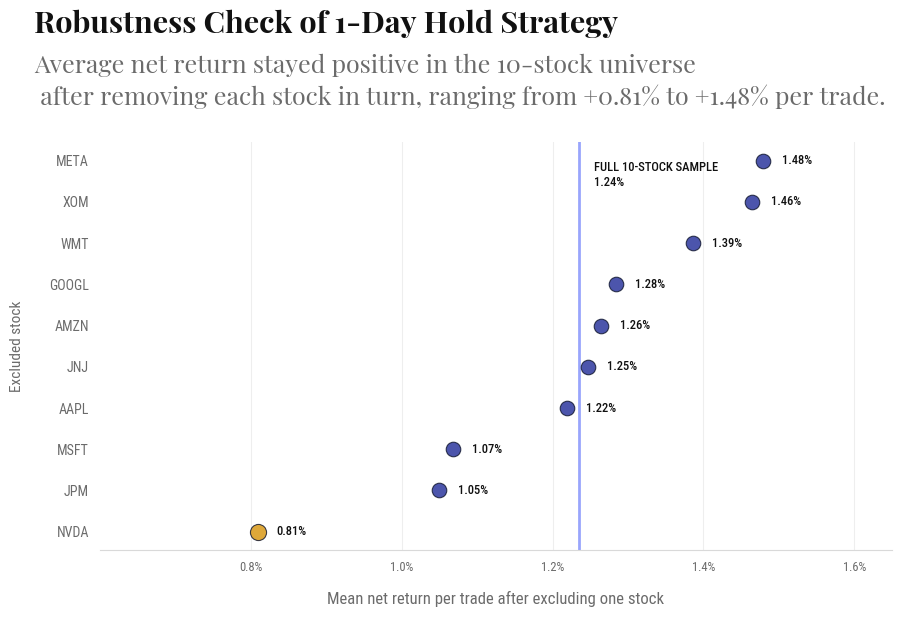

In [184]:
# ---------------------------------------------------------
# FIGURE
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6.8))

fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

# Match the spacing/composition of the previous visuals
fig.subplots_adjust(
    left=0.16,
    right=0.88,
    bottom=0.15,
    top=0.75
)

# ---------------------------------------------------------
# FULL-SAMPLE REFERENCE
# ---------------------------------------------------------

# This line shows the strategy result when all 10 stocks
# are included: +1.24% mean net return per trade.
ax.axvline(
    baseline_return,
    color=CHROMIS_2,
    linewidth=2,
    alpha=0.80,
    zorder=1
)

# ---------------------------------------------------------
# LEAVE-ONE-OUT RESULTS
# ---------------------------------------------------------

y_positions = np.arange(len(loo_plot))

# Plot each leave-one-stock-out result individually so
# NVDA can be highlighted.
for y, row in loo_plot.iterrows():

    is_nvda = row["Excluded_Ticker"] == "NVDA"

    ax.scatter(
        row["Mean_Net_Return_Pct"],
        y,
        s=135 if is_nvda else 110,
        color=CHROMIS_4 if is_nvda else CHROMIS_1,
        alpha=0.80,
        edgecolor=CHROMIS_0,
        linewidth=0.8,
        zorder=3
    )

# ---------------------------------------------------------
# VALUE LABELS
# ---------------------------------------------------------

for y, row in loo_plot.iterrows():

    value = row["Mean_Net_Return_Pct"]

    ax.text(
        value + 0.025,
        y,
        f"{value:.2f}%",
        fontproperties=ROBOTO_MEDIUM,
        fontsize=9,
        color=BLACK,
        va="center"
    )

# ---------------------------------------------------------
# EDITORIAL TITLE + SUBTITLE
# ---------------------------------------------------------

fig.text(
    0.10,
    0.91,
    "Robustness Check of 1-Day Hold Strategy",
    fontproperties=PLAYFAIR_BOLD,
    fontsize=22,
    color=BLACK,
    ha="left"
)

fig.text(
    0.10,
    0.805,
    "Average net return stayed positive in the 10-stock universe \n after removing each stock in turn,"
    " ranging from +0.81% to +1.48% per trade.",
    fontproperties=PLAYFAIR_REGULAR,
    fontsize=18,
    color=GREY,
    ha="left",
    linespacing=1.35
)

# ---------------------------------------------------------
# Y-AXIS
# ---------------------------------------------------------

# Instead of repeatedly writing "Without AAPL",
# the axis title explains what the ticker names represent.
ax.set_yticks(y_positions)

ax.set_yticklabels(
    loo_plot["Excluded_Ticker"],
    fontproperties=ROBOTO_REGULAR,
    fontsize=10,
    color=GREY
)

ax.set_ylabel(
    "Excluded stock",
    fontproperties=ROBOTO_REGULAR,
    fontsize=11,
    color=GREY,
    labelpad=18
)

# ---------------------------------------------------------
# X-AXIS
# ---------------------------------------------------------

ax.set_xlim(0.6, 1.65)

ax.set_xticks([0.8, 1.0, 1.2, 1.4, 1.6])

ax.set_xticklabels(
    ["0.8%", "1.0%", "1.2%", "1.4%", "1.6%"],
    fontproperties=ROBOTO_REGULAR,
    fontsize=9,
    color=GREY
)

ax.set_xlabel(
    "Mean net return per trade after excluding one stock",
    fontproperties=ROBOTO_REGULAR,
    fontsize=12,
    color=GREY,
    labelpad=12
)

ax.tick_params(
    axis="both",
    length=0,
    pad=8
)

# ---------------------------------------------------------
# BASELINE LABEL
# ---------------------------------------------------------

ax.text(
    baseline_return + 0.02,
    len(loo_plot) - 1.0,
    f"FULL 10-STOCK SAMPLE\n{baseline_return:.2f}%",
    fontproperties=ROBOTO_MEDIUM,
    fontsize=9,
    color=BLACK,
    ha="left",
    va="top",
    linespacing=1.25
)

# ---------------------------------------------------------
# CHART FURNITURE
# ---------------------------------------------------------

# Remove unnecessary borders.
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color(LIGHT_GREY)
ax.spines["bottom"].set_linewidth(0.8)

# Very light vertical guides.
for x in [0.8, 1.0, 1.2, 1.4, 1.6]:

    ax.axvline(
        x,
        color=VERY_LIGHT_GREY,
        linewidth=0.8,
        zorder=0
    )

# ---------------------------------------------------------
# EXPORT
# ---------------------------------------------------------

output_path = "04_strategy_robustness_check.jpg"

fig.savefig(
    output_path,
    format="jpg",
    dpi=300,
    bbox_inches="tight",
    facecolor=WHITE,
    pil_kwargs={"quality": 95}
)

print(f"Saved: {output_path}")

plt.show()

## 7. Visual 5: Incorporating Transaction Costs to the Model 

Does the 1-day strategy still work once we make trading increasingly expensive?


In [185]:
print("TRANSACTION COST SENSITIVITY")
print("=" * 70)
print(transaction_costs.to_string(index=False))

print("\nCOLUMNS")
print("=" * 70)
print(transaction_costs.columns.tolist())

TRANSACTION COST SENSITIVITY
Group  Trades  Mean_Net_Return  Median_Net_Return  Win_Rate  Profit_Factor  Best_Trade  Worst_Trade  Average_MFE  Average_MAE  Round_Trip_Cost
0.00%      60         0.013354           0.008306  0.566667       2.288964    0.112039    -0.105631     0.036329    -0.035945           0.0000
0.10%      60         0.012354           0.007306  0.566667       2.144572    0.111039    -0.106631     0.036329    -0.035945           0.0010
0.25%      60         0.010854           0.005806  0.566667       1.948486    0.109539    -0.108131     0.036329    -0.035945           0.0025
0.50%      60         0.008354           0.003306  0.550000       1.666139    0.107039    -0.110631     0.036329    -0.035945           0.0050
1.00%      60         0.003354          -0.001694  0.483333       1.224352    0.102039    -0.115631     0.036329    -0.035945           0.0100

COLUMNS
['Group', 'Trades', 'Mean_Net_Return', 'Median_Net_Return', 'Win_Rate', 'Profit_Factor', 'Best_Trade', '

✓ Saved: 05_transaction_cost_sensitivity.jpg


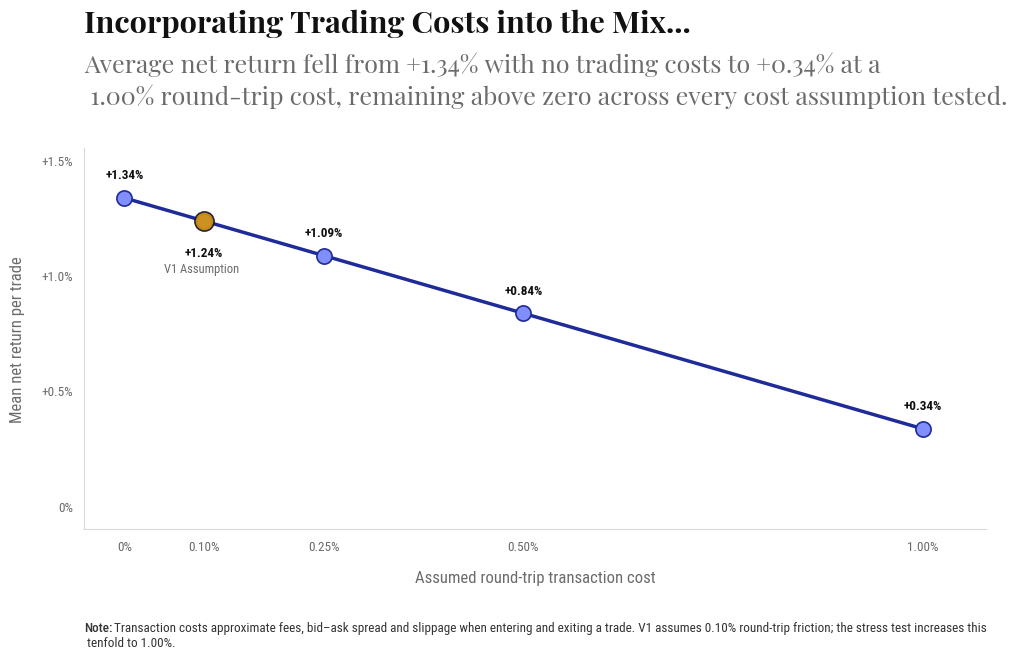

In [210]:
# ---------------------------------------------------------
# GRAPHIC 05
# Transaction-cost sensitivity
# ---------------------------------------------------------

# Make a copy so we do not alter the original dataframe.
cost_plot = transaction_costs.copy()

# Convert decimal values into percentages for plotting.
# Example: 0.001 becomes 0.10%
cost_plot["Cost_Pct"] = cost_plot["Round_Trip_Cost"] * 100
cost_plot["Mean_Return_Pct"] = cost_plot["Mean_Net_Return"] * 100


# ---------------------------------------------------------
# FIGURE
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6.8))

fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

# Keep the same overall composition as the earlier visuals.
fig.subplots_adjust(
    left=0.10,
    right=0.92,
    bottom=0.18,
    top=0.74
)


# ---------------------------------------------------------
# MAIN LINE
# ---------------------------------------------------------

ax.plot(
    cost_plot["Cost_Pct"],
    cost_plot["Mean_Return_Pct"],
    color=CHROMIS_1,
    linewidth=2.5,
    zorder=2
)

# Plot the tested cost assumptions as individual points.
ax.scatter(
    cost_plot["Cost_Pct"],
    cost_plot["Mean_Return_Pct"],
    s=120,
    color=CHROMIS_2,
    edgecolor=CHROMIS_1,
    linewidth=1.2,
    zorder=3
)


# ---------------------------------------------------------
# HIGHLIGHT V1 ASSUMPTION
# ---------------------------------------------------------

v1_row = cost_plot.loc[
    np.isclose(cost_plot["Round_Trip_Cost"], 0.001)
].iloc[0]

ax.scatter(
    v1_row["Cost_Pct"],
    v1_row["Mean_Return_Pct"],
    s=190,
    color=CHROMIS_4,
    alpha=0.90,
    edgecolor=CHROMIS_0,
    linewidth=1.2,
    zorder=5
)

# ---------------------------------------------------------
# TITLE + SUBTITLE
# ---------------------------------------------------------

fig.text(
    0.10,
    0.91,
    "Incorporating Trading Costs into the Mix...",
    fontproperties=PLAYFAIR_BOLD,
    fontsize=22,
    color=BLACK,
    ha="left"
)

fig.text(
    0.10,
    0.805,
    "Average net return fell from +1.34% with no trading costs to +0.34% at a \n 1.00% round-trip cost,"
    " remaining above zero across every cost assumption tested.",
    fontproperties=PLAYFAIR_REGULAR,
    fontsize=18,
    color=GREY,
    ha="left",
    linespacing=1.35
)


# ---------------------------------------------------------
# VALUE LABELS
# ---------------------------------------------------------

# Instead of using the same placement for every point,
# we control each label individually.
#
# This matters because the first three points sit quite
# close together on the x-axis.

label_positions = {
    0.00: {"dx": 0.00, "dy": 0.07, "ha": "center"},
    0.25: {"dx": 0.00, "dy": 0.07, "ha": "center"},
    0.50: {"dx": 0.00, "dy": 0.07, "ha": "center"},
    1.00: {"dx": 0.00, "dy": 0.07, "ha": "center"},
}

for _, row in cost_plot.iterrows():

    cost = round(row["Cost_Pct"], 2)

    # V1 gets a separate annotation below.
    if np.isclose(cost, 0.10):
        continue

    pos = label_positions[cost]

    ax.text(
        row["Cost_Pct"] + pos["dx"],
        row["Mean_Return_Pct"] + pos["dy"],
        f"+{row['Mean_Return_Pct']:.2f}%",
        fontproperties=ROBOTO_BOLD,
        fontsize=9.5,
        color=BLACK,
        ha=pos["ha"],
        va="bottom"
    )


# ---------------------------------------------------------
# V1 ASSUMPTION ANNOTATION
# ---------------------------------------------------------

# Put the annotation below/right of the ochre point.
# This separates it from the neighbouring 0.25% point.

ax.text(
    v1_row["Cost_Pct"] - 0.025,
    v1_row["Mean_Return_Pct"] - 0.11,
    "+1.24%",
    fontproperties=ROBOTO_BOLD,
    fontsize=9.5,
    color=BLACK,
    ha="left",
    va="top"
)

ax.text(
    v1_row["Cost_Pct"] - 0.05,
    v1_row["Mean_Return_Pct"] - 0.18,
    "V1 Assumption",
    fontproperties=ROBOTO_REGULAR,
    fontsize=9,
    color=GREY,
    ha="left",
    va="top"
)


# ---------------------------------------------------------
# AXES
# ---------------------------------------------------------

ax.set_xlim(-0.05, 1.08)
ax.set_ylim(-0.10, 1.55)

ax.set_xticks([0, 0.10, 0.25, 0.50, 1.00])
ax.set_xticklabels(
    ["0%", "0.10%", "0.25%", "0.50%", "1.00%"],
    fontproperties=ROBOTO_REGULAR,
    fontsize=9.5,
    color=GREY
)

ax.set_yticks([0, 0.5, 1.0, 1.5])
ax.set_yticklabels(
    ["0%", "+0.5%", "+1.0%", "+1.5%"],
    fontproperties=ROBOTO_REGULAR,
    fontsize=9.5,
    color=GREY
)

ax.set_xlabel(
    "Assumed round-trip transaction cost",
    fontproperties=ROBOTO_REGULAR,
    fontsize=12,
    color=GREY,
    labelpad=12
)

ax.set_ylabel(
    "Mean net return per trade",
    fontproperties=ROBOTO_REGULAR,
    fontsize=12,
    color=GREY,
    labelpad=12
)


# ---------------------------------------------------------
# CHART FURNITURE
# ---------------------------------------------------------

# Remove unnecessary borders.
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color(LIGHT_GREY)
ax.spines["bottom"].set_color(LIGHT_GREY)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(
    axis="both",
    length=0,
    pad=8
)

# # Very light horizontal guides.
# for y in [0.5, 1.0, 1.5]:
#     ax.axhline(
#         y,
#         color=VERY_LIGHT_GREY,
#         linewidth=0.8,
#         zorder=0
#     )

# ---------------------------------------------------------
# METHODOLOGY NOTE
# ---------------------------------------------------------

fig.text(
    0.10,
    0.045,
    "Note:",
    fontproperties=ROBOTO_MEDIUM,
    fontsize=9.5,
    color=BLACK,
    alpha=0.85,
    ha="left",
    va="top"
)

fig.text(
    0.10,
    0.045,
    "          Transaction costs approximate fees, bid–ask spread and slippage when entering and exiting a trade. "
    "V1 assumes 0.10% round-trip friction; the stress test increases this \n tenfold to 1.00%.",
    fontproperties=ROBOTO_REGULAR,
    fontsize=9.5,
    color=BLACK,
    alpha=0.85,
    ha="left",
    va="top"
)

# ---------------------------------------------------------
# SAVE FINAL VISUAL
# ---------------------------------------------------------

output_path = "05_transaction_cost_sensitivity.jpg"

plt.savefig(
    output_path,
    format="jpg",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

print(f"✓ Saved: {output_path}")

plt.show()